### Projet de prédiction de l'insécurité alimentaire modérée ou sévère

In [1]:
# %% Importation des bibliothèques
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import joblib

### Chargement du dataset

In [23]:

# %% Chargement des données
data = pd.read_excel("DDDIEMMME.xlsx", sheet_name="Feuil2")


In [8]:
data.head()

,id,q100_region,q101_departement,q114_1_situation_matrimoniale_cm,q115_1_cm_souffre_t_il_maladie_chronique,q116_0_taille_menage,q206_1_type_toilette_utilise,q207_1_principale_source_energie_cuisson,q208_1_principale_source_energie_eclairage,q209_1_principale_source_eau_boisson,...,CATEGORIE_SOCIA_ECO,HAUTEUR_PARTICIPATION,q600_inquiets_de_ne_pas_avoir_suffisamment_de_nourriture,q601_ne_pas_manger_nourriture_saine_nutritive,q602_manger_nourriture_peu_variee,q603_sauter_un_repas,q604_manger_moins_que_ce_que_vous_auriez_du,q605_1_ne_plus_avoir_de_nourriture_pas_suffisamment_d_argent,q606_1_avoir_faim_mais_ne_pas_manger,q607_1_passer_toute_une_journee_sans_manger
0,4807.0,ZIGUINCHOR,ZIGUINCHOR,Marié(e) monogame,Aucune maladie chronique,5.0,Latrines traditionnelles à fosse,Bois de chauffe,Panneau solaire (individuel ou collectif),Robinet dans la concession,...,Salariés dans une PME,[1 ; 20%[,Oui,Non,Non,Non,Non,Non,Non,Non
1,4797.0,ZIGUINCHOR,ZIGUINCHOR,Marié(e) monogame,Aucune maladie chronique,2.0,Latrines traditionnelles à fosse,Bois de chauffe,Panneau solaire (individuel ou collectif),Robinet dans la concession,...,Sans emploi,[1 ; 20%[,Oui,Non,Non,Non,Non,Non,Non,Non
2,4804.0,ZIGUINCHOR,ZIGUINCHOR,Divorcé(e)/veuf (ve),Hyper/hypotension,1.0,Toilette à ciel ouvert (pas de murs),Bois de chauffe,Panneau solaire (individuel ou collectif),"Robinet, eau courante dans les maisons SEN-EAU",...,Sans emploi,[1 ; 20%[,Non,Non,Non,Non,Non,Non,Non,Non
3,4799.0,ZIGUINCHOR,ZIGUINCHOR,Marié(e) polygame,Aucune maladie chronique,16.0,Latrines traditionnelles à fosse,Charbon,Électricité de la SENELEC,Puits traditionnel (non protégé),...,Travailleur pour son propre compte,[1 ; 20%[,Non,Non,Non,Non,Non,Non,Non,Non
4,4800.0,ZIGUINCHOR,ZIGUINCHOR,Marié(e) monogame,Aucune maladie chronique,6.0,Latrines traditionnelles à fosse,Bois de chauffe,Panneau solaire (individuel ou collectif),Robinet dans la concession,...,Travailleur pour son propre compte,[1 ; 20%[,Non,Non,Non,Non,Non,Non,Non,Non


#### Nettoyage du dataset avec quelques exemples

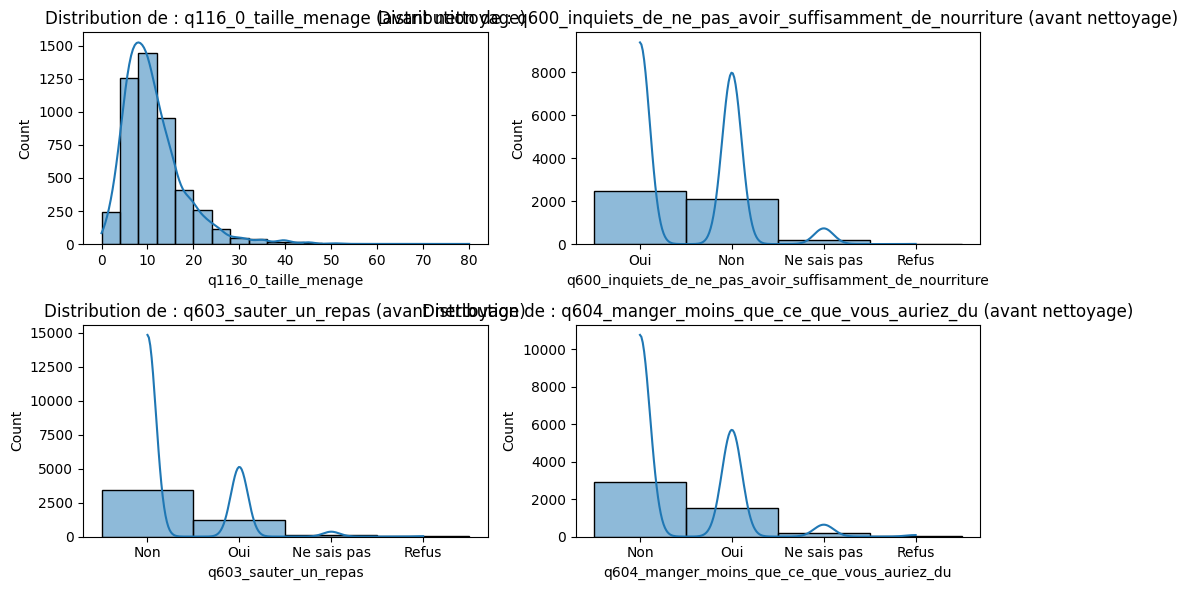

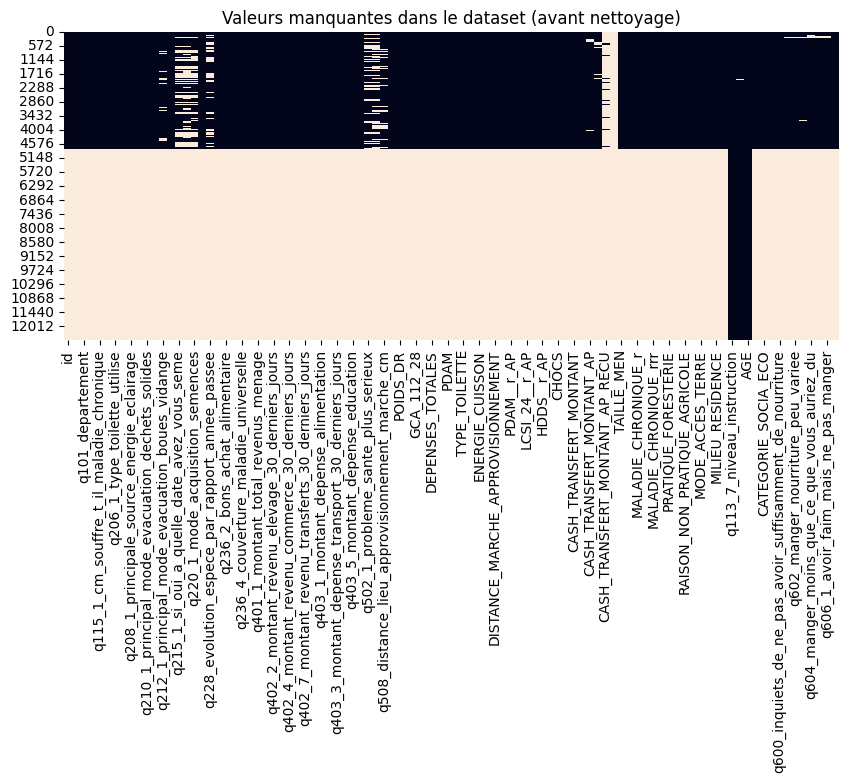

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Liste des variables à afficher
variables = [
    "q116_0_taille_menage", 
    "q600_inquiets_de_ne_pas_avoir_suffisamment_de_nourriture",
    "q603_sauter_un_repas",
    "q604_manger_moins_que_ce_que_vous_auriez_du"
]

# Création d'une grille 4x2
fig, axes = plt.subplots(2,2, figsize=(10,6))

# Boucle sur les variables et les axes
for ax, var in zip(axes.flatten(), variables):
    sns.histplot(data[var], bins=20, kde=True, ax=ax)
    ax.set_title(f"Distribution de : {var} (avant nettoyage)")
    ax.set_xlabel(var)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

# Heatmap des valeurs manquantes
plt.figure(figsize=(10,4))
sns.heatmap(data.isnull(), cbar=False)
plt.title("Valeurs manquantes dans le dataset (avant nettoyage)")
plt.show()


### Nettoyage des données et encodages

In [35]:
# Nettoyage
numeric_cols = data.select_dtypes(include=np.number).columns
data[numeric_cols] = data[numeric_cols].fillna(data[numeric_cols].median())
data.drop_duplicates(inplace=True)

In [36]:
# Encodage simple (LabelEncoder)
from sklearn.preprocessing import LabelEncoder, StandardScaler
label_encoder = LabelEncoder()
for col in data.select_dtypes(include=['object']).columns:
    data[col] = label_encoder.fit_transform(data[col].astype(str))

scaler = StandardScaler()
data[data.select_dtypes(include=['float', 'int']).columns] = scaler.fit_transform(
    data.select_dtypes(include=['float', 'int'])
)


#### Visualisation des variables nettoyer apres normalisation

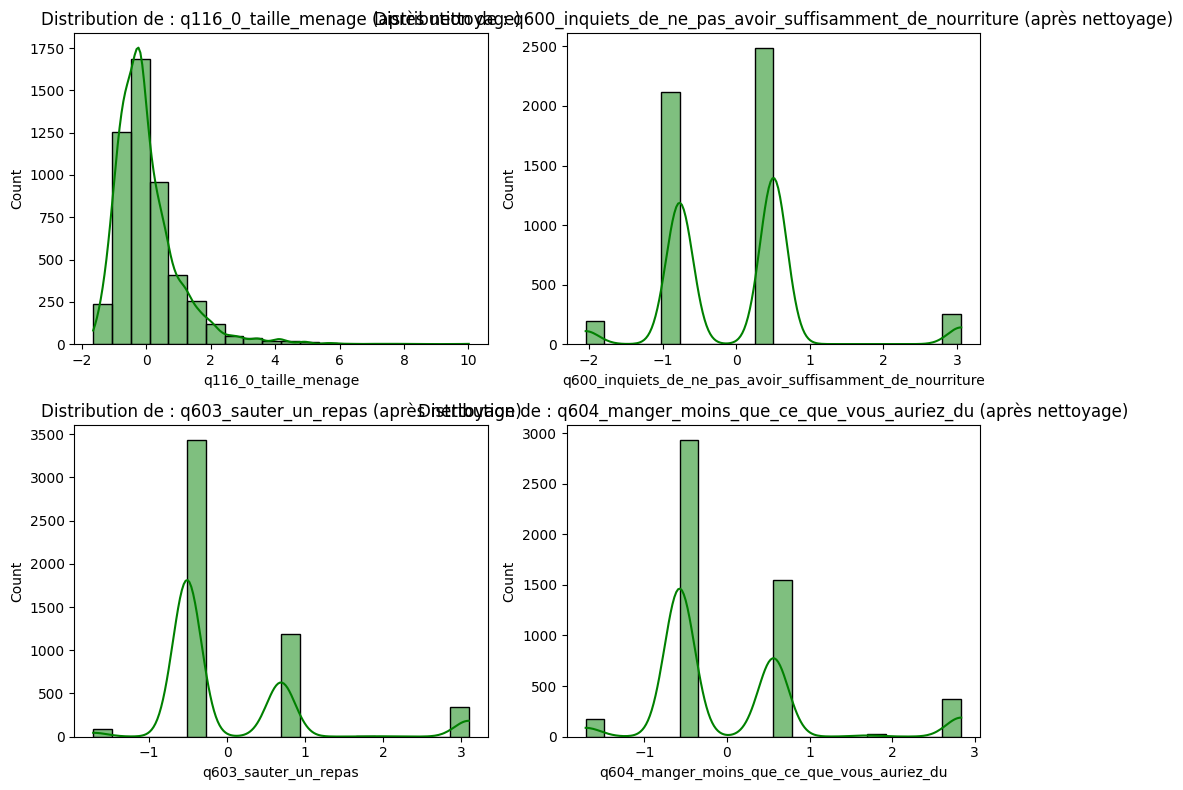

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# Liste des variables à afficher
variables = [
    "q116_0_taille_menage", 
    "q600_inquiets_de_ne_pas_avoir_suffisamment_de_nourriture",
    "q603_sauter_un_repas",
    "q604_manger_moins_que_ce_que_vous_auriez_du"
]

# Création d'une grille 2x2
fig, axes = plt.subplots(2, 2, figsize=(10,8))

# Boucle sur les variables et les axes
for ax, var in zip(axes.flatten(), variables):
    sns.histplot(data[var], bins=20, kde=True, color="green", ax=ax)
    ax.set_title(f"Distribution de : {var} (après nettoyage)")
    ax.set_xlabel(var)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()



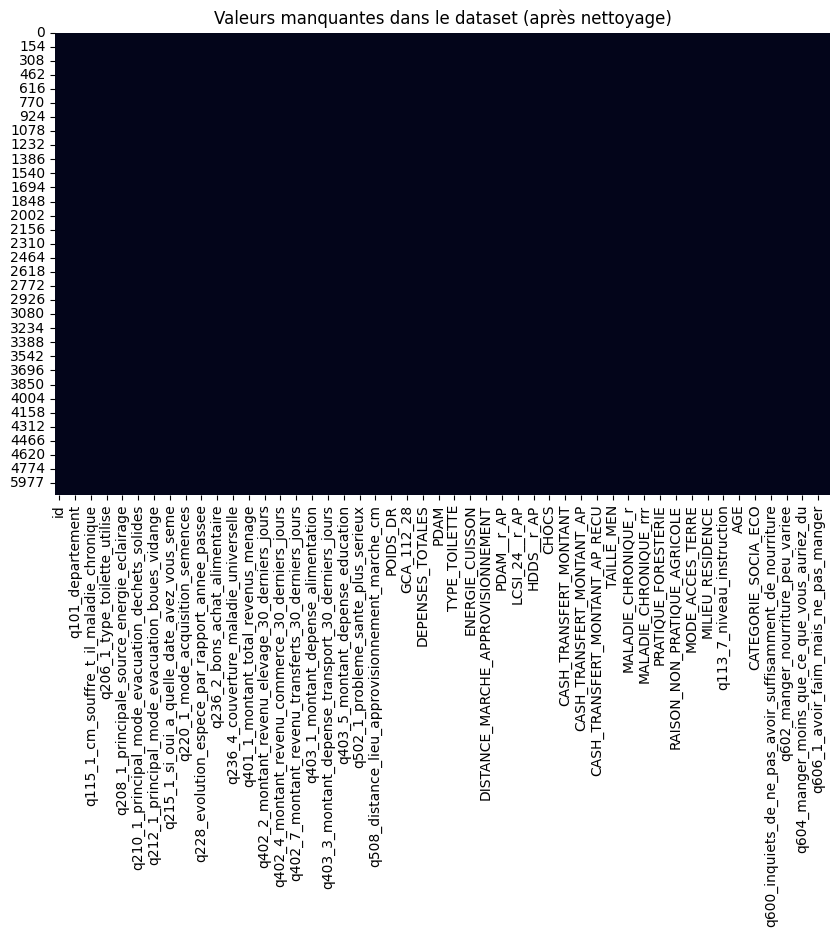

In [39]:
plt.figure(figsize=(10,6))
sns.heatmap(data.isnull(), cbar=False)
plt.title("Valeurs manquantes dans le dataset (après nettoyage)")
plt.show()


#### Distribution avec le boxplot pour voir les valeurs extremes

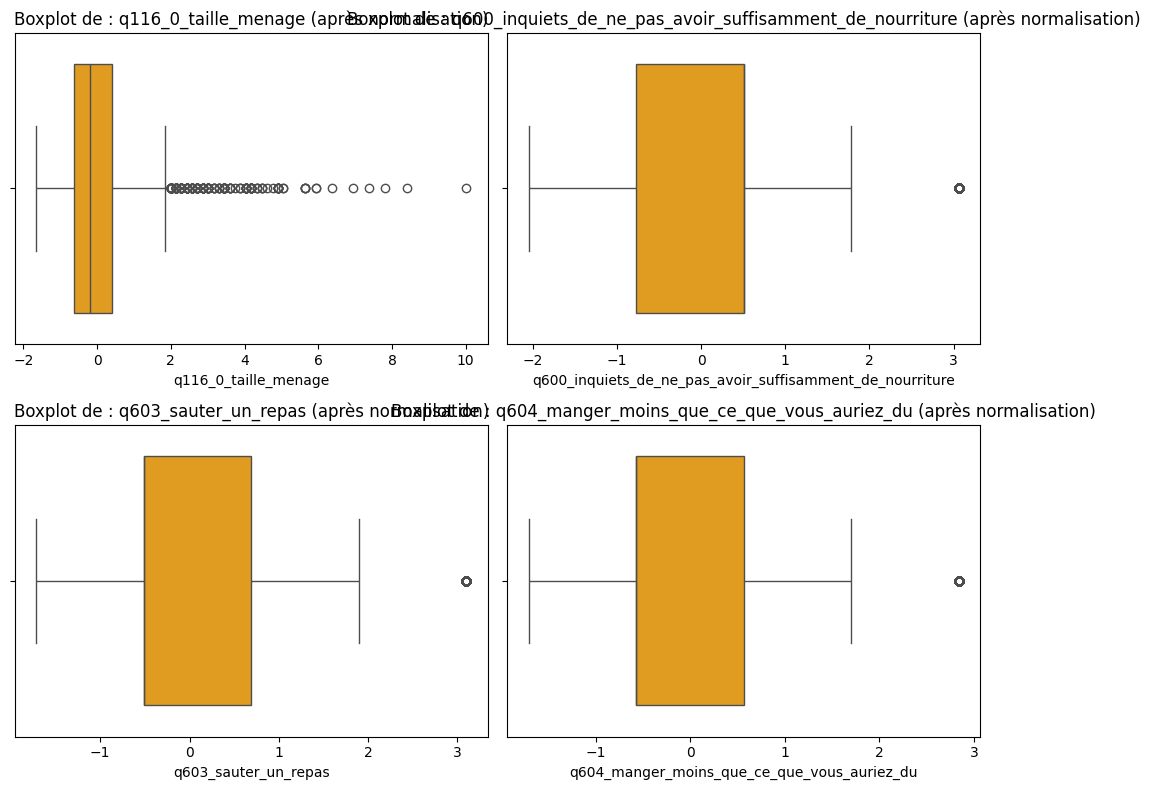

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# Liste des variables à afficher
variables = [
    "q116_0_taille_menage", 
    "q600_inquiets_de_ne_pas_avoir_suffisamment_de_nourriture",
    "q603_sauter_un_repas",
    "q604_manger_moins_que_ce_que_vous_auriez_du"
]

# Création d'une grille 2x2
fig, axes = plt.subplots(2, 2, figsize=(10,8))

# Boucle sur les variables et les axes
for ax, var in zip(axes.flatten(), variables):
    sns.boxplot(x=data[var], ax=ax, color="orange")
    ax.set_title(f"Boxplot de : {var} (après normalisation)")
    ax.set_xlabel(var)

plt.tight_layout()
plt.show()


### Traitement des valeurs extrèmes

In [42]:
# Détection des outliers avec l’IQR
Q1 = data['q116_0_taille_menage'].quantile(0.25)
Q3 = data['q116_0_taille_menage'].quantile(0.75)
IQR = Q3 - Q1

# Filtrer les valeurs extrêmes
data_no_outliers = data[
    (data['q116_0_taille_menage'] >= Q1 - 1.5*IQR) &
    (data['q116_0_taille_menage'] <= Q3 + 1.5*IQR)
]


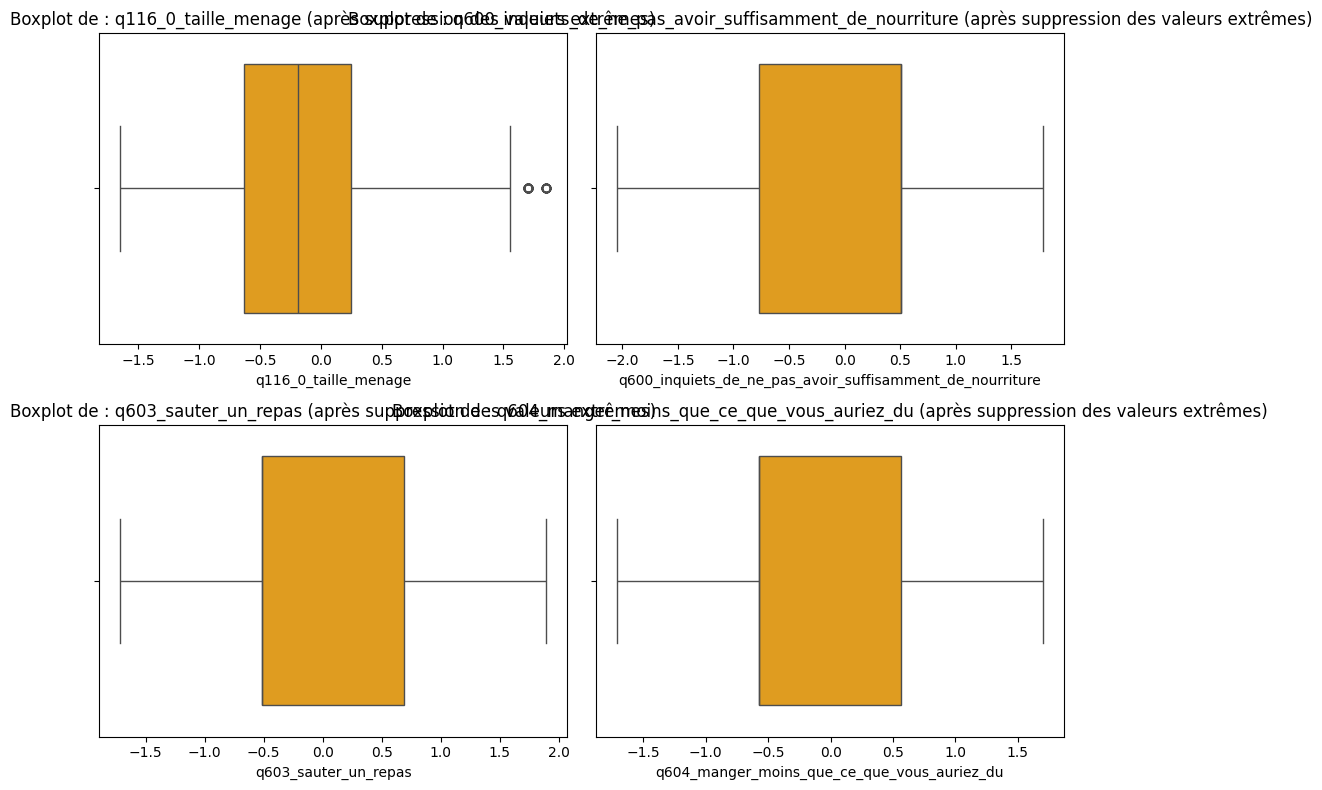

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

# Liste des variables à traiter
variables = [
    "q116_0_taille_menage", 
    "q600_inquiets_de_ne_pas_avoir_suffisamment_de_nourriture",
    "q603_sauter_un_repas",
    "q604_manger_moins_que_ce_que_vous_auriez_du"
]

# Création d'une grille 2x2
fig, axes = plt.subplots(2, 2, figsize=(10,8))

# Boucle sur les variables et les axes
for ax, var in zip(axes.flatten(), variables):
    Q1 = data[var].quantile(0.25)
    Q3 = data[var].quantile(0.75)
    IQR = Q3 - Q1
    
    # Filtrer les outliers
    data_no_outliers = data[
        (data[var] >= Q1 - 1.5*IQR) &
        (data[var] <= Q3 + 1.5*IQR)
    ]
    
    sns.boxplot(x=data_no_outliers[var], ax=ax, color="orange")
    ax.set_title(f"Boxplot de : {var} (après suppression des valeurs extrêmes)")
    ax.set_xlabel(var)

plt.tight_layout()
plt.show()


### Définition et mapping de la variable cible

In [44]:

# %% Définition de la cible insécurité alimentaire
def definir_insécurité_alimentaire(row):
    if sum(row[col] > 1.5 for col in [
        'q605_1_ne_plus_avoir_de_nourriture_pas_suffisamment_d_argent',
        'q606_1_avoir_faim_mais_ne_pas_manger',
        'q607_1_passer_toute_une_journee_sans_manger'
    ]) >= 1:
        return 2
    elif sum(0 < row[col] <= 1.5 for col in [
        'q600_inquiets_de_ne_pas_avoir_suffisamment_de_nourriture',
        'q601_ne_pas_manger_nourriture_saine_nutritive',
        'q602_manger_nourriture_peu_variee',
        'q603_sauter_un_repas',
        'q604_manger_moins_que_ce_que_vous_auriez_du'
    ]) >= 2:
        return 1
    else:
        return 0

data['insécurité_alimentaire'] = data.apply(definir_insécurité_alimentaire, axis=1)

# Sauvegarde avec la colonne incluse
data.to_csv("data_encoded_1.csv", index=False)

In [66]:
data.head(3)

,id,q100_region,q101_departement,q114_1_situation_matrimoniale_cm,q115_1_cm_souffre_t_il_maladie_chronique,q116_0_taille_menage,q206_1_type_toilette_utilise,q207_1_principale_source_energie_cuisson,q208_1_principale_source_energie_eclairage,q209_1_principale_source_eau_boisson,...,HAUTEUR_PARTICIPATION,q600_inquiets_de_ne_pas_avoir_suffisamment_de_nourriture,q601_ne_pas_manger_nourriture_saine_nutritive,q602_manger_nourriture_peu_variee,q603_sauter_un_repas,q604_manger_moins_que_ce_que_vous_auriez_du,q605_1_ne_plus_avoir_de_nourriture_pas_suffisamment_d_argent,q606_1_avoir_faim_mais_ne_pas_manger,q607_1_passer_toute_une_journee_sans_manger,insécurité_alimentaire
0,1.770091,1.656339,1.651499,-0.354250,-0.562660,-0.920372,-0.399249,-0.549378,-1.36538,-0.048352,...,-0.117391,0.506177,-0.742363,-0.674202,-0.512962,-0.573903,-0.384793,-0.399684,-0.327659,0
1,1.762716,1.656339,1.651499,-0.354250,-0.562660,-1.357563,-0.399249,-0.549378,-1.36538,-0.048352,...,-0.117391,0.506177,-0.742363,-0.674202,-0.512962,-0.573903,-0.384793,-0.399684,-0.327659,0
2,1.767879,1.656339,1.651499,-1.628542,1.532907,-1.503293,1.009340,-0.549378,-1.36538,1.345412,...,-0.117391,-0.770380,-0.742363,-0.674202,-0.512962,-0.573903,-0.384793,-0.399684,-0.327659,0


In [45]:
# Filtrer modérée/sévère
data_filtrée = data[data['insécurité_alimentaire'].isin([1, 2])]

X = data_filtrée.drop(columns=['insécurité_alimentaire'])
y = data_filtrée['insécurité_alimentaire'].replace({1: 0, 2: 1})

In [46]:
data.shape

(5054, 99)

In [47]:
data.describe()

,id,q100_region,q101_departement,q114_1_situation_matrimoniale_cm,q115_1_cm_souffre_t_il_maladie_chronique,q116_0_taille_menage,q206_1_type_toilette_utilise,q207_1_principale_source_energie_cuisson,q208_1_principale_source_energie_eclairage,q209_1_principale_source_eau_boisson,...,HAUTEUR_PARTICIPATION,q600_inquiets_de_ne_pas_avoir_suffisamment_de_nourriture,q601_ne_pas_manger_nourriture_saine_nutritive,q602_manger_nourriture_peu_variee,q603_sauter_un_repas,q604_manger_moins_que_ce_que_vous_auriez_du,q605_1_ne_plus_avoir_de_nourriture_pas_suffisamment_d_argent,q606_1_avoir_faim_mais_ne_pas_manger,q607_1_passer_toute_une_journee_sans_manger,insécurité_alimentaire
count,5054.000000,5.054000e+03,5.054000e+03,5.054000e+03,5.054000e+03,5.054000e+03,5.054000e+03,5.054000e+03,5.054000e+03,5.054000e+03,...,5.054000e+03,5.054000e+03,5.054000e+03,5.054000e+03,5.054000e+03,5.054000e+03,5.054000e+03,5.054000e+03,5.054000e+03,5054.000000
mean,0.000000,-7.873050e-17,8.997771e-17,-2.136971e-16,-7.873050e-17,5.623607e-17,5.061246e-17,2.249443e-17,4.498886e-17,-1.799554e-16,...,-1.124721e-17,-1.237194e-16,3.374164e-17,5.623607e-17,-4.498886e-17,-9.560132e-17,-2.811803e-17,2.811803e-17,-8.997771e-17,0.590621
std,1.000099,1.000099e+00,1.000099e+00,1.000099e+00,1.000099e+00,1.000099e+00,1.000099e+00,1.000099e+00,1.000099e+00,1.000099e+00,...,1.000099e+00,1.000099e+00,1.000099e+00,1.000099e+00,1.000099e+00,1.000099e+00,1.000099e+00,1.000099e+00,1.000099e+00,0.628185
min,-1.774517,-1.616291e+00,-1.669060e+00,-4.177126e+00,-9.817737e-01,-1.649023e+00,-2.512131e+00,-1.349078e+00,-3.067419e+00,-2.835882e+00,...,-1.104843e+00,-2.046937e+00,-2.006056e+00,-1.873153e+00,-1.715983e+00,-1.710911e+00,-1.553508e+00,-1.591425e+00,-1.663134e+00,0.000000
25%,-0.842822,-8.610690e-01,-9.143871e-01,-3.542502e-01,-5.626602e-01,-6.289120e-01,-3.992487e-01,-5.493783e-01,-6.561975e-01,-5.129407e-01,...,-7.756921e-01,-7.703797e-01,-7.423631e-01,-6.742023e-01,-5.129619e-01,-5.739031e-01,-3.847926e-01,-3.996838e-01,-3.276590e-01,0.000000
50%,0.000000,-1.058467e-01,-8.780123e-03,-3.542502e-01,-5.626602e-01,-1.917214e-01,3.050455e-01,-5.493783e-01,3.366584e-01,-4.835247e-02,...,-1.173910e-01,5.061773e-01,-7.423631e-01,-6.742023e-01,-5.129619e-01,-5.739031e-01,-3.847926e-01,-3.996838e-01,-3.276590e-01,1.000000
75%,0.842822,9.011164e-01,8.968268e-01,9.200419e-01,-1.435468e-01,3.911994e-01,1.009340e+00,2.503216e-01,9.040046e-01,8.808239e-01,...,7.054855e-01,5.061773e-01,5.213294e-01,5.247486e-01,6.900588e-01,5.631044e-01,-3.847926e-01,-3.996838e-01,-3.276590e-01,1.000000
max,1.774517,1.908080e+00,1.726967e+00,2.194334e+00,2.790247e+00,1.000939e+01,1.713634e+00,2.649421e+00,9.040046e-01,1.810000e+00,...,2.186663e+00,3.059291e+00,3.048714e+00,2.922650e+00,3.096100e+00,2.837119e+00,3.121353e+00,3.175540e+00,3.678765e+00,2.000000


### Division en train/test

In [48]:
# %% Division train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Entrainement du modèle avec RandomForest et prédiction

In [49]:
# %% Entraînement RandomForest
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=4,
    min_samples_leaf=10,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42
)
rf.fit(X_train, y_train)

from sklearn.metrics import classification_report

# Prédictions sur le jeu de test
rf_preds = rf.predict(X_test)
print("rf_preds:", rf_preds[:20])

# Rapport de classification
print("📊 Rapport RandomForest :")
print(classification_report(y_test, rf_preds))


rf_preds: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1]
📊 Rapport RandomForest :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       439
           1       1.00      0.98      0.99        81

    accuracy                           1.00       520
   macro avg       1.00      0.99      0.99       520
weighted avg       1.00      1.00      1.00       520



### Extraction des importances 

✅ Comparaison des 5 variables les plus importantes :
                                RandomForest_feature  RandomForest_importance
0      q601_ne_pas_manger_nourriture_saine_nutritive                 0.062054
1                               q603_sauter_un_repas                 0.083059
2               q606_1_avoir_faim_mais_ne_pas_manger                 0.096366
3  q605_1_ne_plus_avoir_de_nourriture_pas_suffisa...                 0.118685
4        q604_manger_moins_que_ce_que_vous_auriez_du                 0.128681


C:\Users\HP\AppData\Local\Temp\ipykernel_16124\425717912.py:23: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


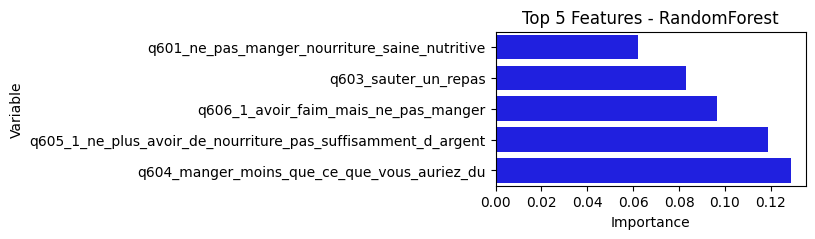

In [50]:
# 🔍 Extraire les importances
rf_importances = rf.feature_importances_
rf_top5_idx = np.argsort(rf_importances)[-5:]
rf_top5_features = X_train.columns[rf_top5_idx]
rf_top5_values = rf_importances[rf_top5_idx]

# 🔍 Construire DataFrame comparatif
df_top5 = pd.DataFrame({
    "RandomForest_feature": rf_top5_features,
    "RandomForest_importance": rf_top5_values
})

print("✅ Comparaison des 5 variables les plus importantes :")
print(df_top5)


# 🔹 Graphique
plt.figure(figsize=(4, 2))
sns.barplot(x=rf_top5_values, y=rf_top5_features, color="blue")
plt.title("Top 5 Features - RandomForest")
plt.xlabel("Importance")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

### Selection des features importantes

In [62]:
# Sélection des features importantes
importances = rf.feature_importances_
indices_top5 = np.argsort(importances)[-5:]
selected_features = X_train.columns[indices_top5].tolist()

print("✅ Variables retenues :", selected_features)


✅ Variables retenues : ['q601_ne_pas_manger_nourriture_saine_nutritive', 'q603_sauter_un_repas', 'q606_1_avoir_faim_mais_ne_pas_manger', 'q605_1_ne_plus_avoir_de_nourriture_pas_suffisamment_d_argent', 'q604_manger_moins_que_ce_que_vous_auriez_du']


In [73]:
# Réentraînement avec les 5 features
rf_selected = RandomForestClassifier(n_estimators=100, random_state=42)
rf_selected.fit(X_train[selected_features], y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

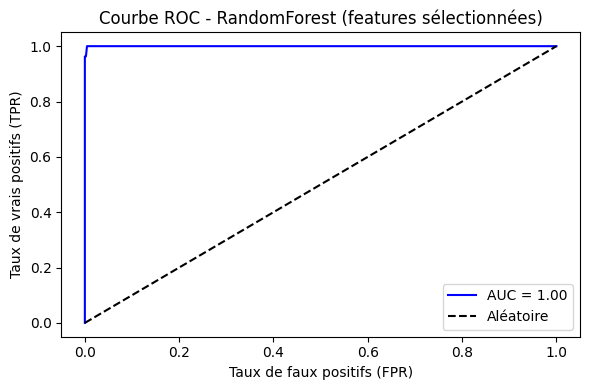

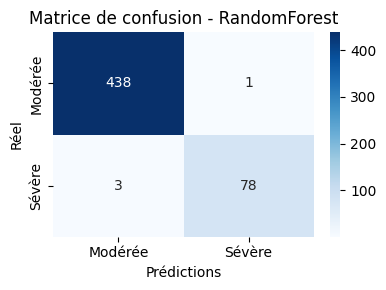

In [74]:
from sklearn.metrics import roc_curve, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 🔹 Courbe ROC
y_proba = rf_selected.predict_proba(X_test[selected_features])[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_proba):.2f}", color="blue")
plt.plot([0, 1], [0, 1], "k--", label="Aléatoire")
plt.xlabel("Taux de faux positifs (FPR)")
plt.ylabel("Taux de vrais positifs (TPR)")
plt.title("Courbe ROC - RandomForest (features sélectionnées)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# 🔹 Matrice de confusion
y_pred = rf_selected.predict(X_test[selected_features])
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Modérée", "Sévère"], yticklabels=["Modérée", "Sévère"])
plt.xlabel("Prédictions")
plt.ylabel("Réel")
plt.title("Matrice de confusion - RandomForest")
plt.tight_layout()
plt.show()


c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:17:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


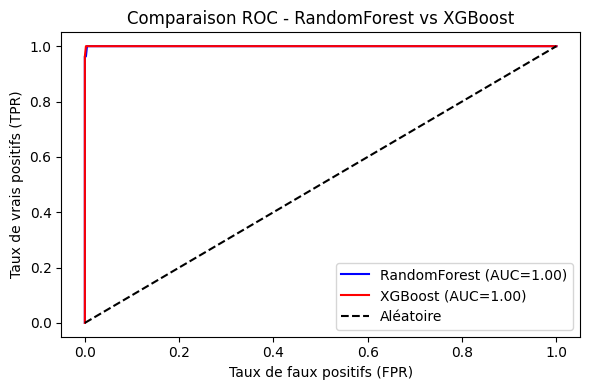

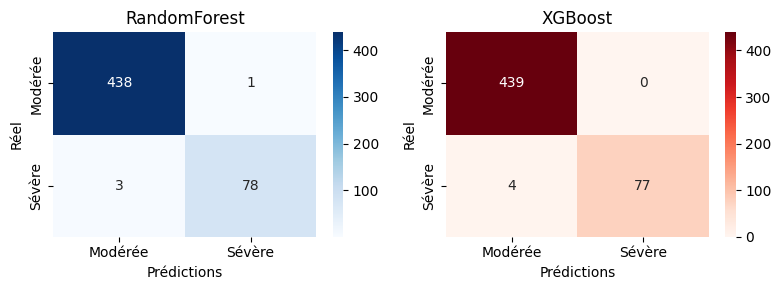

In [66]:
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 🔹 Entraînement XGBoost
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss"
)
xgb.fit(X_train[selected_features], y_train)

# 🔹 Prédictions et probabilités
y_pred_xgb = xgb.predict(X_test[selected_features])
y_proba_xgb = xgb.predict_proba(X_test[selected_features])[:, 1]

# 🔹 Courbes ROC comparatives
y_proba_rf = rf_selected.predict_proba(X_test[selected_features])[:, 1]

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)

plt.figure(figsize=(6, 4))
plt.plot(fpr_rf, tpr_rf, label=f"RandomForest (AUC={roc_auc_score(y_test, y_proba_rf):.2f})", color="blue")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC={roc_auc_score(y_test, y_proba_xgb):.2f})", color="red")
plt.plot([0, 1], [0, 1], "k--", label="Aléatoire")
plt.xlabel("Taux de faux positifs (FPR)")
plt.ylabel("Taux de vrais positifs (TPR)")
plt.title("Comparaison ROC - RandomForest vs XGBoost")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# 🔹 Matrices de confusion comparatives
cm_rf = confusion_matrix(y_test, rf_selected.predict(X_test[selected_features]))
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

fig, axes = plt.subplots(1, 2, figsize=(8, 3))

sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Modérée", "Sévère"], yticklabels=["Modérée", "Sévère"], ax=axes[0])
axes[0].set_title("RandomForest")
axes[0].set_xlabel("Prédictions")
axes[0].set_ylabel("Réel")

sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Reds",
            xticklabels=["Modérée", "Sévère"], yticklabels=["Modérée", "Sévère"], ax=axes[1])
axes[1].set_title("XGBoost")
axes[1].set_xlabel("Prédictions")
axes[1].set_ylabel("Réel")

plt.tight_layout()
plt.show()


In [67]:
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score
import pandas as pd

# 🔹 Calcul des métriques pour RandomForest
rf_report = classification_report(y_test, rf_selected.predict(X_test[selected_features]), output_dict=True)
rf_auc = roc_auc_score(y_test, rf_selected.predict_proba(X_test[selected_features])[:, 1])

# 🔹 Calcul des métriques pour XGBoost
xgb_report = classification_report(y_test, y_pred_xgb, output_dict=True)
xgb_auc = roc_auc_score(y_test, y_proba_xgb)

# 🔹 Tableau comparatif
df_comparatif = pd.DataFrame({
    "Modèle": ["RandomForest", "XGBoost"],
    "Accuracy": [accuracy_score(y_test, rf_selected.predict(X_test[selected_features])),
                 accuracy_score(y_test, y_pred_xgb)],
    "Recall (Sévère)": [rf_report["1"]["recall"], xgb_report["1"]["recall"]],
    "F1-score (Sévère)": [rf_report["1"]["f1-score"], xgb_report["1"]["f1-score"]],
    "AUC": [rf_auc, xgb_auc]
})

print("📊 Comparaison des métriques principales :")
print(df_comparatif)


📊 Comparaison des métriques principales :
         Modèle  Accuracy  Recall (Sévère)  F1-score (Sévère)       AUC
0  RandomForest  0.992308         0.962963           0.975000  0.999873
1       XGBoost  0.992308         0.950617           0.974684  0.999958


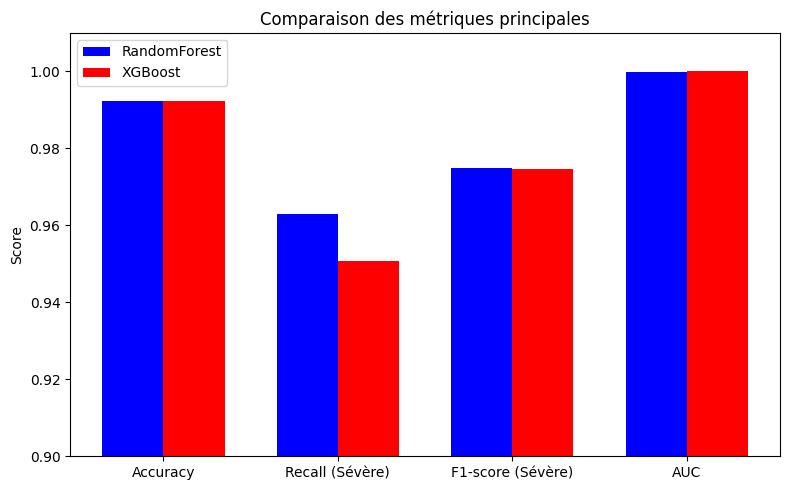

In [68]:
import matplotlib.pyplot as plt

# 🔹 Visualisation des métriques principales
metrics = ["Accuracy", "Recall (Sévère)", "F1-score (Sévère)", "AUC"]
rf_values = [df_comparatif.loc[0, m] for m in metrics]
xgb_values = [df_comparatif.loc[1, m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, rf_values, width, label="RandomForest", color="blue")
plt.bar(x + width/2, xgb_values, width, label="XGBoost", color="red")

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.ylim(0.9, 1.01)
plt.title("Comparaison des métriques principales")
plt.legend()
plt.tight_layout()
plt.show()


### Sauvegarde de notre modèle

In [69]:
# Sauvegarde du modèle
joblib.dump({"model": rf_selected, "features": selected_features}, "modele_food_insecurity_best.pkl")
print("✅ Modèle sauvegardé avec succès")


✅ Modèle sauvegardé avec succès


In [70]:
# Entraînement XGBoost
xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(X_train[selected_features], y_train)

# Sauvegarde avec les features
joblib.dump({"model": xgb_model, "features": selected_features}, "modele_food_insecurity_xgb.pkl")
print("✅ Modèle XGBoost sauvegardé avec succès")


✅ Modèle XGBoost sauvegardé avec succès


In [71]:
# %% Prédiction exemple
bundle = joblib.load("modele_food_insecurity_best.pkl")
model = bundle["model"]
selected_features = bundle["features"]
print("", selected_features)


 ['q601_ne_pas_manger_nourriture_saine_nutritive', 'q603_sauter_un_repas', 'q606_1_avoir_faim_mais_ne_pas_manger', 'q605_1_ne_plus_avoir_de_nourriture_pas_suffisamment_d_argent', 'q604_manger_moins_que_ce_que_vous_auriez_du']


### Exemple de prédiction avec de nouvelle données

In [72]:

# Construire new_data avec exactement les colonnes attendues
data_dict = {col: 0 for col in selected_features}  # valeurs par défaut
data_dict.update({
    "q600_inquiets_de_ne_pas_avoir_suffisamment_de_nourriture": 2,
    "q601_ne_pas_manger_nourriture_saine_nutritive": 3,
    "q602_manger_nourriture_peu_variee": 0,
    "q603_sauter_un_repas": 1,
    "q604_manger_moins_que_ce_que_vous_auriez_du": 0,
    "q605_1_ne_plus_avoir_de_nourriture_pas_suffisamment_d_argent": 0,
    "q606_1_avoir_faim_mais_ne_pas_manger": 1,
    "q607_1_passer_toute_une_journee_sans_manger": 0
})

new_data = pd.DataFrame([data_dict])[selected_features]

prediction = model.predict(new_data)[0]
proba = model.predict_proba(new_data)[0][1]

mapping = {
    0: "Insécurité alimentaire modérée",
    1: "Insécurité alimentaire sévère"
}
print("🎯 Résultat :", mapping[prediction])
print("📊 Probabilité :", round(proba, 3))


🎯 Résultat : Insécurité alimentaire modérée
📊 Probabilité : 0.09
